In [1]:
# ============================================================
# ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# Dataset: SIPaKMeD - Cáncer Cervical
# Proyecto: Sistema de Detección de Cáncer con IA
# Autor: Marco Soliz Guzman
# Fecha: Febrero 2026
# ============================================================

# Importar librerías
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path

# Configuración
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

# Ruta del dataset
DATA_PATH = Path("../data/archive")

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [2]:
# ============================================================
# 1. INFORMACIÓN DEL DATASET
# ============================================================

print("""
╔══════════════════════════════════════════════════════════════╗
║              DATASET SIPaKMeD - CÁNCER CERVICAL              ║
╠══════════════════════════════════════════════════════════════╣
║  Descripción: Imágenes de células de Papanicolaou (Pap)      ║
║  Fuente: Universidad de Atenas                               ║
║  Uso: Detección temprana de cáncer de cuello uterino         ║
╚══════════════════════════════════════════════════════════════╝
""")

# Obtener clases y contar imágenes
clases = [d.name for d in DATA_PATH.iterdir() if d.is_dir()]

conteo = {}
for clase in clases:
    clase_path = DATA_PATH / clase / clase
    if clase_path.exists():
        imagenes = list(clase_path.glob("*.bmp"))
        conteo[clase] = len(imagenes)

# Crear DataFrame
df_conteo = pd.DataFrame({
    'Clase': list(conteo.keys()),
    'Cantidad': list(conteo.values())
}).sort_values('Cantidad', ascending=False)

total = df_conteo['Cantidad'].sum()
anormales = conteo['im_Dyskeratotic'] + conteo['im_Koilocytotic']
normales = total - anormales

print(f"📊 Total de imágenes: {total}")
print(f"📐 Dimensiones: 2048 x 1536 píxeles")
print(f"\n⚖️ Balance:")
print(f"   • Anormales: {anormales} ({anormales/total*100:.1f}%)")
print(f"   • Normales:  {normales} ({normales/total*100:.1f}%)")


╔══════════════════════════════════════════════════════════════╗
║              DATASET SIPaKMeD - CÁNCER CERVICAL              ║
╠══════════════════════════════════════════════════════════════╣
║  Descripción: Imágenes de células de Papanicolaou (Pap)      ║
║  Fuente: Universidad de Atenas                               ║
║  Uso: Detección temprana de cáncer de cuello uterino         ║
╚══════════════════════════════════════════════════════════════╝

📊 Total de imágenes: 966
📐 Dimensiones: 2048 x 1536 píxeles

⚖️ Balance:
   • Anormales: 461 (47.7%)
   • Normales:  505 (52.3%)


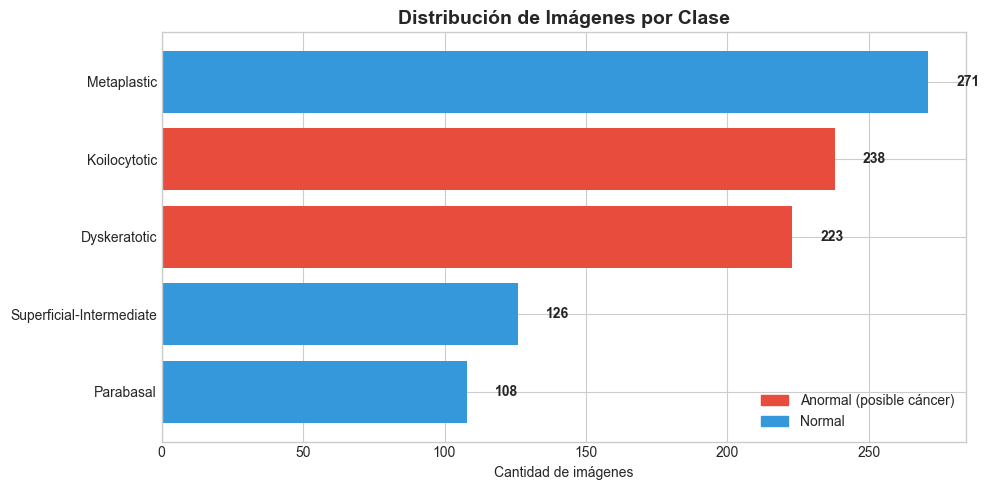

In [3]:
# ============================================================
# 2. DISTRIBUCIÓN DE CLASES
# ============================================================

# Clasificar tipos
tipos = {
    'im_Dyskeratotic': ('Dyskeratotic', 'Anormal', '#e74c3c'),
    'im_Koilocytotic': ('Koilocytotic', 'Anormal', '#e74c3c'),
    'im_Metaplastic': ('Metaplastic', 'Normal', '#3498db'),
    'im_Parabasal': ('Parabasal', 'Normal', '#3498db'),
    'im_Superficial-Intermediate': ('Superficial-Intermediate', 'Normal', '#3498db')
}

df_conteo['Nombre'] = df_conteo['Clase'].map(lambda x: tipos[x][0])
df_conteo['Tipo'] = df_conteo['Clase'].map(lambda x: tipos[x][1])
df_conteo['Color'] = df_conteo['Clase'].map(lambda x: tipos[x][2])

# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_conteo['Nombre'], df_conteo['Cantidad'], color=df_conteo['Color'])
ax.set_xlabel('Cantidad de imágenes')
ax.set_title('Distribución de Imágenes por Clase', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for bar, valor in zip(bars, df_conteo['Cantidad']):
    ax.text(valor + 10, bar.get_y() + bar.get_height()/2, str(valor), va='center', fontweight='bold')

# Leyenda
from matplotlib.patches import Patch
leyenda = [Patch(color='#e74c3c', label='Anormal (posible cáncer)'),
           Patch(color='#3498db', label='Normal')]
ax.legend(handles=leyenda, loc='lower right')

plt.tight_layout()
plt.savefig('../data/01_distribucion_clases.png', dpi=150)
plt.show()

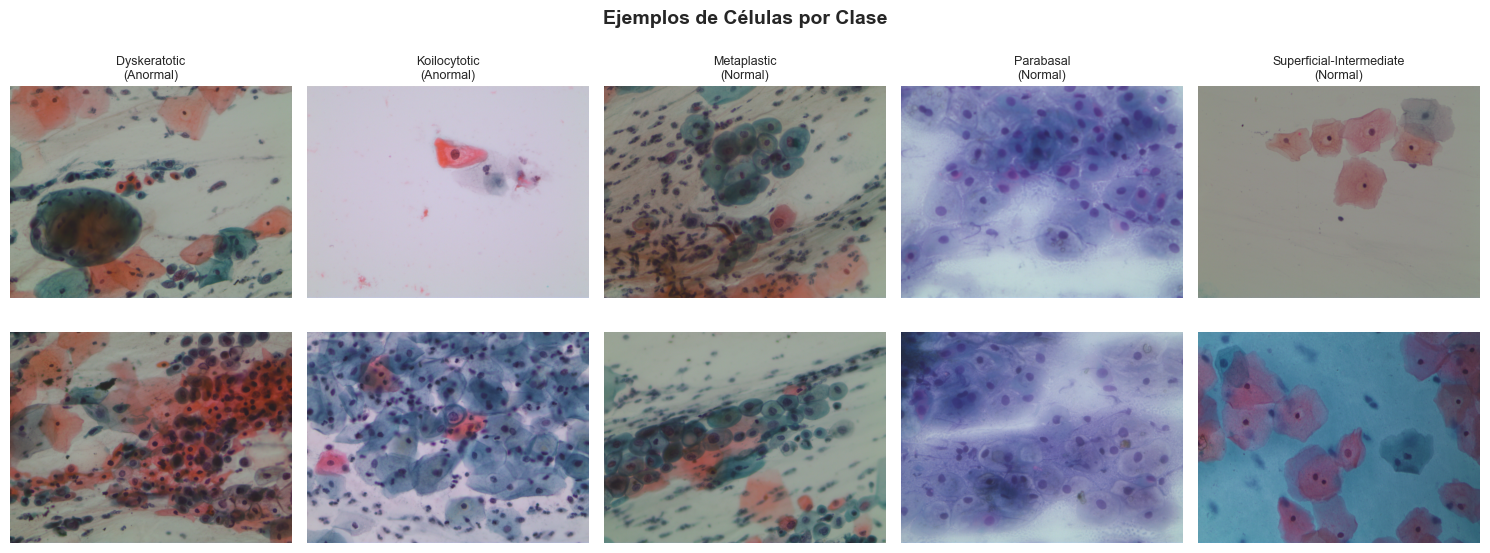

In [4]:
# ============================================================
# 3. EJEMPLOS DE IMÁGENES POR CLASE
# ============================================================

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for idx, clase in enumerate(clases):
    clase_path = DATA_PATH / clase / clase
    imagenes = list(clase_path.glob("*.bmp"))
    nombre = tipos[clase][0]
    tipo = tipos[clase][1]
    
    if imagenes:
        # Fila superior
        img1 = Image.open(imagenes[0])
        axes[0, idx].imshow(img1)
        axes[0, idx].set_title(f"{nombre}\n({tipo})", fontsize=9)
        axes[0, idx].axis('off')
        
        # Fila inferior
        img2 = Image.open(imagenes[1])
        axes[1, idx].imshow(img2)
        axes[1, idx].axis('off')

plt.suptitle('Ejemplos de Células por Clase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/02_ejemplos_clases.png', dpi=150)
plt.show()

In [5]:
# ============================================================
# 4. CONCLUSIONES DEL EDA
# ============================================================

print("""
╔══════════════════════════════════════════════════════════════╗
║                    CONCLUSIONES DEL EDA                      ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  ✅ Dataset balanceado (47.7% anormal vs 52.3% normal)       ║
║                                                              ║
║  ✅ Imágenes de alta resolución (2048 x 1536 px)             ║
║                                                              ║
║  ✅ 5 clases bien definidas:                                 ║
║     • 2 anormales: Dyskeratotic, Koilocytotic                ║
║     • 3 normales: Metaplastic, Parabasal, Superficial        ║
║                                                              ║
║  📋 PRÓXIMOS PASOS:                                          ║
║     1. Redimensionar imágenes a 224x224 px                   ║
║     2. Dividir en train/validation/test (70/15/15)           ║
║     3. Aplicar Data Augmentation                             ║
║     4. Entrenar modelo CNN con Transfer Learning             ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║                    CONCLUSIONES DEL EDA                      ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  ✅ Dataset balanceado (47.7% anormal vs 52.3% normal)       ║
║                                                              ║
║  ✅ Imágenes de alta resolución (2048 x 1536 px)             ║
║                                                              ║
║  ✅ 5 clases bien definidas:                                 ║
║     • 2 anormales: Dyskeratotic, Koilocytotic                ║
║     • 3 normales: Metaplastic, Parabasal, Superficial        ║
║                                                              ║
║  📋 PRÓXIMOS PASOS:                                          ║
║     1. Redimensionar imágenes a 224x224 px                   ║
║     2. Dividir en train/validation/test (70/15/15)           ║
║     3. Aplicar Data Augmen